In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(84).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(44).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(245).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/6.jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(238).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(196).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(108).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(310).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image (5).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(186).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(29).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(140).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(224).jpg

In [2]:
!pip install pennylane

In [3]:
!pip install monai

  Using cached monai-1.5.0-py3-none-any.whl.metadata (13 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nvjitlink_cu12-12.4.127-py3-none-manylinux

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-07-16 04:45:04.300855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752641104.490077     110 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752641104.544873     110 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


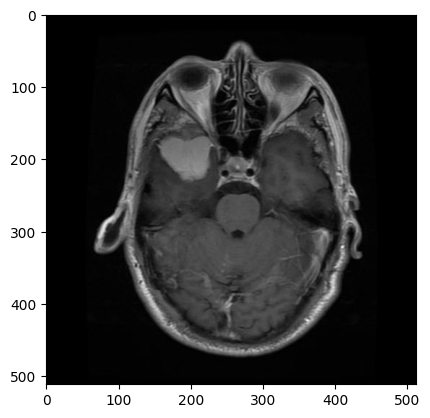

In [4]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from monai.transforms import ScaleIntensity
import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler, random_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm

import pennylane as qml
from pennylane import numpy as np

import warnings
warnings.filterwarnings("ignore")



path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
dataset_path_train = f'{path}/Training'
dataset_path_test = f'{path}/Testing'
img_size = (224, 224)
class_names = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
samples_per_class = 2000

brain_image = cv2.imread(f'{dataset_path_train}/meningioma_tumor/m1(39).jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(brain_image, cmap='gray')

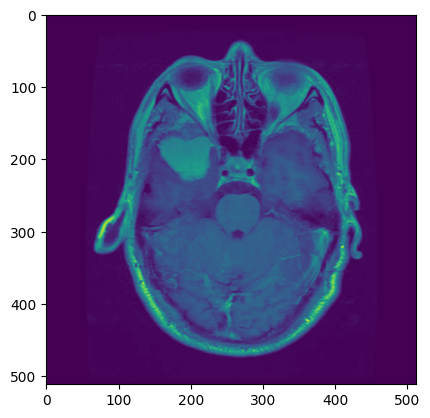

In [5]:
transform_img = ScaleIntensity(minv=0.0, maxv=1.0)
brain_image_scaled = transform_img(brain_image)
colored_kid = cm.viridis(brain_image_scaled)
plt.imshow(colored_kid)

In [6]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

label_encoder = LabelEncoder()

def load_images_from_folder(folder, label, transform):
    data, labels = [], []
    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = Image.open(img_path).convert("RGB")
            img = transform(img)
            data.append(img)
            labels.append(label)
        except Exception as e:
            print(f"[Warning] Error loading {img_path}: {e}")
    return data, labels

def load_dataset(dataset_path, transform, limit_per_class=None):
    X_all, y_all = [], []
    for class_name in class_names:
        folder = os.path.join(dataset_path, class_name)
        X_class, y_class = load_images_from_folder(folder, class_name, transform)
        if limit_per_class and len(X_class) > 0:
            X_class, y_class = resample(X_class, y_class, replace=True, n_samples=limit_per_class, random_state=42)
        X_all.extend(X_class)
        y_all.extend(y_class)
    label_encoder.fit(y_all)
    y_encoded = label_encoder.transform(y_all)
    return torch.stack(X_all), torch.tensor(y_encoded)
X_train, y_train = load_dataset(dataset_path_train, train_transform, samples_per_class)
X_test, y_test = load_dataset(dataset_path_test, test_transform, samples_per_class // 2)

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: torch.Size([8000, 3, 224, 224]) torch.Size([8000])
Test set: torch.Size([4000, 3, 224, 224]) torch.Size([4000])


In [11]:
def create_dataframe_from_directory(directory, class_names):
    data = []
    for label in class_names:
        folder = os.path.join(directory, label)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                filepath = os.path.join(folder, fname)
                data.append({'filepaths': filepath, 'labels': label})
    return pd.DataFrame(data)

train_df = create_dataframe_from_directory(dataset_path_train, class_names)
train_df = train_df.sample(frac=1).reset_index(drop=True)

def scalar(img):
    return img

batch_size = 32

tr_gen = ImageDataGenerator(preprocessing_function=scalar)

train_gen = tr_gen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

g_dict = train_gen.class_indices     
classes = list(g_dict.keys())       
images, labels = next(train_gen)  
plt.figure(figsize=(20, 20))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255.0
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color='blue', fontsize=12)
    plt.axis('off')
plt.show()

Found 2870 validated image filenames belonging to 4 classes.


Using device: cuda


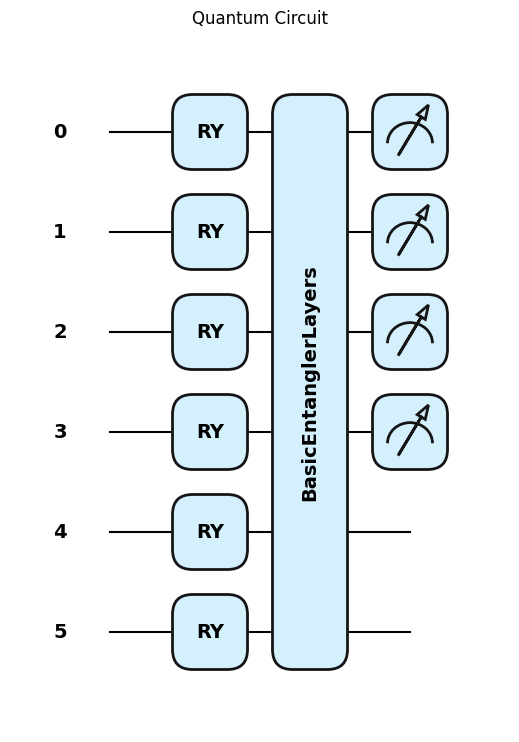

In [12]:
class_indices = label_encoder.transform(class_names)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_indices,
    y=y_train.numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

counts = np.bincount(y_train.numpy(), minlength=len(class_names))
counts[counts == 0] = 1  # prevent division by zero
weights = 1. / counts
samples_weights = torch.from_numpy(weights[y_train.numpy()]).double()
sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda")
print(f"Using device: {device}")

qdevice = qml.device("default.qubit", wires=6)
@qml.qnode(qdevice, interface="torch")
def quantum_circuit(inputs, weights):
    for i in range(6):
        qml.RY(inputs[i % len(inputs)], wires=i)
    qml.templates.BasicEntanglerLayers(weights, wires=range(6))
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

q_shapes = {"weights": (4, 6)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, q_shapes).to(device)
dummy_input = torch.tensor([0.1, 0.2, 0.3, 0.4], requires_grad=False)
dummy_weights = torch.rand(q_shapes['weights'])
qml.draw_mpl(quantum_circuit, style="pennylane")(dummy_input, dummy_weights)
plt.title("Quantum Circuit")
plt.show()


--- Training Quantum + ResNet Model ---


Epoch 1, Val Loss: 1.1344, Val Acc: 0.5075


Epoch 2, Val Loss: 1.0098, Val Acc: 0.7250


Epoch 3, Val Loss: 0.9268, Val Acc: 0.9475


Epoch 4, Val Loss: 0.8311, Val Acc: 0.9762


Epoch 5, Val Loss: 0.7500, Val Acc: 0.9875
Accuracy: 0.6625
Classification Report:
                   precision    recall  f1-score   support

    glioma_tumor       0.81      0.20      0.33      1000
meningioma_tumor       0.60      0.98      0.74      1000
        no_tumor       0.60      0.96      0.74      1000
 pituitary_tumor       1.00      0.51      0.67      1000

        accuracy                           0.66      4000
       macro avg       0.75      0.66      0.62      4000
    weighted avg       0.75      0.66      0.62      4000



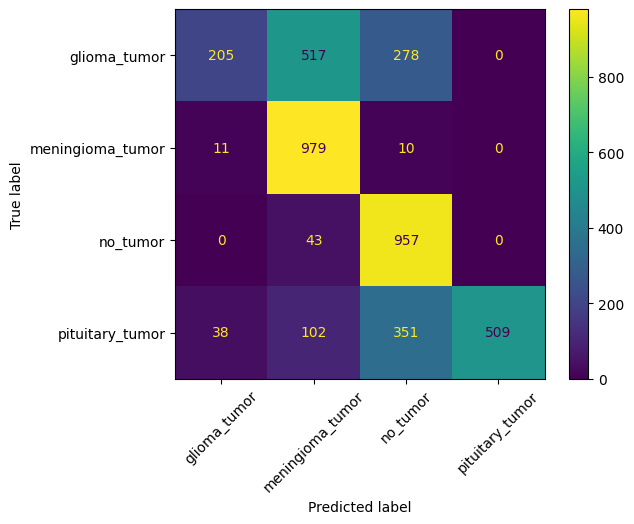

([1,
  2,
  1,
  1,
  0,
  2,
  2,
  2,
  1,
  1,
  2,
  0,
  1,
  1,
  0,
  2,
  1,
  2,
  1,
  1,
  1,
  2,
  2,
  2,
  2,
  0,
  0,
  0,
  0,
  2,
  1,
  2,
  2,
  1,
  2,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  2,
  1,
  1,
  2,
  2,
  2,
  1,
  2,
  1,
  0,
  2,
  2,
  1,
  1,
  2,
  1,
  0,
  1,
  2,
  1,
  1,
  0,
  1,
  1,
  0,
  1,
  2,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  2,
  1,
  2,
  1,
  1,
  1,
  2,
  1,
  0,
  2,
  0,
  2,
  1,
  1,
  0,
  2,
  1,
  2,
  1,
  2,
  1,
  2,
  1,
  0,
  0,
  2,
  2,
  0,
  1,
  2,
  1,
  0,
  1,
  1,
  2,
  1,
  0,
  2,
  1,
  1,
  1,
  0,
  1,
  1,
  2,
  2,
  2,
  0,
  2,
  2,
  1,
  1,
  1,
  2,
  2,
  1,
  1,
  2,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  2,
  1,
  2,
  1,
  1,
  1,
  1,
  1,
  2,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  0,
  2,
  1,
  1,
  1,
  2,
  0,
  0,
  1,
  2,
  2,
  1,
  2,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  2,
  1,
  1,


In [16]:
class QuantumResNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model = models.resnet18(pretrained=True)
        self.base_model.fc = nn.Identity()
        self.fc1 = nn.Linear(512, 6)
        self.quantum = quantum_layer
        self.fc2 = nn.Linear(4, 4)

    def forward(self, x):
        x = self.base_model(x)
        x = self.fc1(x)
        x = torch.stack([self.quantum(sample) for sample in x])
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

class LabelSmoothingNLLLoss(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        logprobs = pred
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        if self.weight is not None:
            nll_loss = nll_loss * self.weight[target]
            smooth_loss = smooth_loss * self.weight[target]
        return (confidence * nll_loss + self.smoothing * smooth_loss).mean()

def train_model(model, loader, epochs=5, patience=3):
    model.to(device)
    train_size = int(0.9 * len(loader.dataset))
    val_size = len(loader.dataset) - train_size
    train_data, val_data = random_split(loader.dataset, [train_size, val_size])
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-5)
    criterion = LabelSmoothingNLLLoss(smoothing=0.1, weight=class_weights.to(device))
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)
        for X_batch, y_batch in loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct/total)

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                out = model(X_val)
                val_loss += criterion(out, y_val).item()
                pred = out.argmax(dim=1)
                val_correct += (pred == y_val).sum().item()

        val_acc = val_correct / len(val_data)
        val_loss /= len(val_loader)
        print(f"Epoch {epoch+1}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping.")
                break

def evaluate_model(model, loader):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            pred = out.argmax(dim=1).cpu().numpy()
            y_pred.extend(pred)
            y_true.extend(y_batch.numpy())
    print("Accuracy:", metrics.accuracy_score(y_true, y_pred))
    print("Classification Report:\n", metrics.classification_report(y_true, y_pred, target_names=class_names))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names, xticks_rotation=45)
    plt.show()
    return y_pred, y_true 

model = QuantumResNetClassifier()
print("\n--- Training Quantum + ResNet Model ---")
history = train_model(model, train_loader)
evaluate_model(model, test_loader)